In [1]:
import numpy, torch, cv2
print("NumPy:", numpy.__version__)
print("PyTorch:", torch.__version__)
print("OpenCV:", cv2.__version__)


NumPy: 1.26.4
PyTorch: 2.2.2+cpu
OpenCV: 4.8.1


In [ ]:
import gymnasium as gym
import ale_py  # ensure backend loads

# This will automatically register Atari envs
print("ALE environments:", [env_id for env_id in gym.registry.keys() if "ALE/" in env_id][:10])

env = gym.make("ALE/MarioBros-v5", render_mode="human")
print("Action space:", env.action_space)
print("Observation space:", env.observation_space)

obs, info = env.reset()
for _ in range(200):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        obs, info = env.reset()
env.close()


ALE environments: ['ALE/Adventure-v5', 'ALE/Adventure-ram-v5', 'ALE/AirRaid-v5', 'ALE/AirRaid-ram-v5', 'ALE/Alien-v5', 'ALE/Alien-ram-v5', 'ALE/Amidar-v5', 'ALE/Amidar-ram-v5', 'ALE/Assault-v5', 'ALE/Assault-ram-v5']
Action space: Discrete(18)
Observation space: Box(0, 255, (210, 160, 3), uint8)


In [ ]:


import gymnasium as gym
import ale_py
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
from tqdm import trange
from gymnasium.wrappers import GrayScaleObservation, ResizeObservation, FrameStack

# Configuration
ALLOWED_ACTIONS = [0, 1, 2, 3, 4]  # map to ALE action IDs (choose the subset you want)
IMG_SIZE = (84, 84)
STACK = 4

# Environment Setup
env = gym.make("ALE/MarioBros-v5", render_mode="rgb_array")

# Print raw env action space info (before we reduce)
print("Raw action space size (env):", env.action_space.n)

# Apply wrappers for preprocessing
env = GrayScaleObservation(env)          # returns (H, W) grayscale frames
env = ResizeObservation(env, IMG_SIZE)   # resize to IMG_SIZE
env = FrameStack(env, STACK)             # stacks STACK frames -> observation shape (H, W, STACK)

# After wrappers, observation_space will be updated
obs_shape = env.observation_space.shape  # e.g. (84, 84, 4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Policy network will output Q-values for the reduced action set
n_policy_actions = len(ALLOWED_ACTIONS)
print(f"✅ Env ready | Obs shape (post-wrap): {obs_shape} | Device: {device} | Policy actions: {n_policy_actions}")

# 2️⃣ DQN Network
class DQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super().__init__()
        c = input_shape[0]  # channels
        self.net = nn.Sequential(
            nn.Conv2d(c, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3136, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        # expect x: (B, C, H, W), uint8 or float
        x = x / 255.0
        return self.net(x)

# Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states),
            np.array(actions),
            np.array(rewards, dtype=np.float32),
            np.array(next_states),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.buffer)

# Helper Functions
def preprocess(obs):
    """Convert observation -> (C, H, W) where C == STACK"""
    arr = np.array(obs)  # FrameStack produces (H, W, STACK)
    if arr.ndim == 3 and arr.shape[-1] == STACK:  # (H, W, STACK)
        arr = np.transpose(arr, (2, 0, 1))  # -> (STACK, H, W)
    elif arr.ndim == 3 and arr.shape[0] == STACK:  # already (C, H, W)
        pass
    else:
        raise ValueError(f"Unexpected obs shape from env: {arr.shape}")
    return arr  # dtype=uint8

def select_action(state, epsilon, policy_net):
    """state: numpy array (C,H,W)"""
    if random.random() < epsilon:
        # Randomly choose index from reduced action set
        return random.randrange(n_policy_actions)
    with torch.no_grad():
        s = torch.tensor(state, device=device, dtype=torch.float32).unsqueeze(0)  # (1,C,H,W)
        qvals = policy_net(s)
        return int(qvals.argmax(1).item())

# Initialize Components
# build network with channels = STACK
policy_net = DQN((STACK, IMG_SIZE[0], IMG_SIZE[1]), n_policy_actions).to(device)
target_net = DQN((STACK, IMG_SIZE[0], IMG_SIZE[1]), n_policy_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=1e-4)
replay = ReplayBuffer()
gamma = 0.99

#  Training Loop (small demo)
num_episodes = 5
batch_size = 32
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay = 10_000
target_update = 1000
global_step = 0

print("🚀 Training started...\n")

for episode in range(num_episodes):
    obs, _ = env.reset()
    state = preprocess(obs)  # (C,H,W)
    assert state.shape == (STACK, IMG_SIZE[0], IMG_SIZE[1]), f"Bad init state shape {state.shape}"
    done = False
    total_reward = 0
    epsilon = max(epsilon_end, epsilon_start - global_step / epsilon_decay)

    while not done:
        # pick index in reduced action space
        action_idx = select_action(state, epsilon, policy_net)
        # map to actual env action id
        env_action = ALLOWED_ACTIONS[action_idx]

        next_obs, reward, terminated, truncated, _ = env.step(env_action)
        done = terminated or truncated
        next_state = preprocess(next_obs)

        # store action as the index in reduced action space (not the env id) to match policy outputs
        replay.push(state, action_idx, reward, next_state, done)

        state = next_state
        total_reward += reward
        global_step += 1

        # Training
        if len(replay) > batch_size:
            states, actions, rewards, next_states, dones = replay.sample(batch_size)
            # states: (B, C, H, W) as numpy
            states = torch.tensor(states, dtype=torch.float32, device=device)
            actions = torch.tensor(actions, dtype=torch.long, device=device).unsqueeze(1)  # indices into reduced set
            rewards = torch.tensor(rewards, dtype=torch.float32, device=device)
            next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
            dones = torch.tensor(dones, dtype=torch.float32, device=device)

            # Sanity check
            assert states.shape[1:] == (STACK, IMG_SIZE[0], IMG_SIZE[1]), f"Bad state shape: {states.shape}"

            q_values = policy_net(states).gather(1, actions).squeeze(1)  # (B,)
            with torch.no_grad():
                max_next_q = target_net(next_states).max(1)[0]
                target_q = rewards + gamma * max_next_q * (1 - dones)

            loss = nn.functional.smooth_l1_loss(q_values, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Update target network periodically
        if global_step % target_update == 0 and global_step > 0:
            target_net.load_state_dict(policy_net.state_dict())

    print(f"Episode {episode+1}/{num_episodes} | Reward: {total_reward:.2f} | ε: {epsilon:.3f}")

env.close()
print("\n✅ Training finished successfully! 🎮")


Raw action space size (env): 18
✅ Env ready | Obs shape (post-wrap): (4, 84, 84) | Device: cpu | Policy actions: 5
🚀 Training started...

Episode 1/5 | Reward: 0.00 | ε: 1.000
Episode 2/5 | Reward: 0.00 | ε: 0.938
Episode 3/5 | Reward: 1600.00 | ε: 0.861
Episode 4/5 | Reward: 0.00 | ε: 0.751
Episode 5/5 | Reward: 0.00 | ε: 0.710

✅ Training finished successfully! 🎮


## Plot Added

✅ Env ready | Obs shape: (4, 84, 84) | Device: cpu


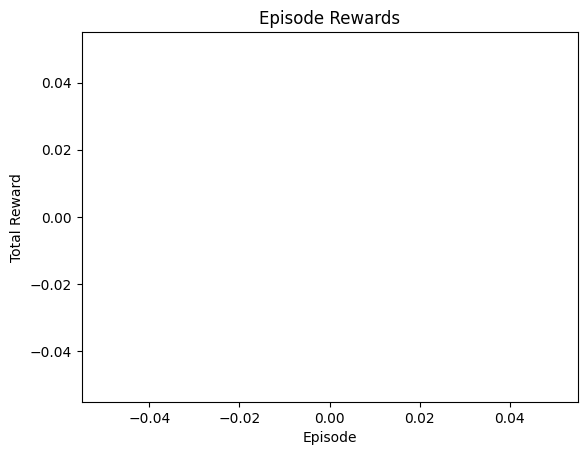

🚀 Training started...



e:\pjt\RL\Super Mario\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:335: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(


Ep 1/10 | Reward: 0.00 | ε: 1.000
Ep 2/10 | Reward: 0.00 | ε: 0.932
Ep 3/10 | Reward: 1600.00 | ε: 0.890
Ep 4/10 | Reward: 0.00 | ε: 0.715
Ep 5/10 | Reward: 0.00 | ε: 0.675
Ep 6/10 | Reward: 0.00 | ε: 0.607
Ep 7/10 | Reward: 0.00 | ε: 0.534
Ep 8/10 | Reward: 0.00 | ε: 0.444
Ep 9/10 | Reward: 0.00 | ε: 0.350
Ep 10/10 | Reward: 0.00 | ε: 0.278

✅ Training finished! 🎮 Video saved as mario_training.mp4


In [ ]:


import gymnasium as gym
import ale_py
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt
from collections import deque
from gymnasium.wrappers import GrayScaleObservation, ResizeObservation, FrameStack


ALLOWED_ACTIONS = [0, 1, 2, 3, 4]   # simplify control set
IMG_SIZE = (84, 84)
STACK = 4
RENDER_FREQ = 4                     # show every N frames


env = gym.make("ALE/MarioBros-v5", render_mode="rgb_array")
env = GrayScaleObservation(env)
env = ResizeObservation(env, IMG_SIZE)
env = FrameStack(env, STACK)
obs_shape = env.observation_space.shape
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ Env ready | Obs shape: {obs_shape} | Device: {device}")

class DQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super().__init__()
        c, h, w = input_shape
        self.net = nn.Sequential(
            nn.Conv2d(c, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3136, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = x / 255.0
        return self.net(x)

class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (
            np.array(s),
            np.array(a),
            np.array(r, dtype=np.float32),
            np.array(ns),
            np.array(d, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)

def preprocess(obs):
    arr = np.array(obs)
    if arr.shape[-1] == STACK:
        arr = np.transpose(arr, (2, 0, 1))
    return arr

def select_action(state, epsilon, policy_net):
    if random.random() < epsilon:
        return random.randrange(len(ALLOWED_ACTIONS))
    with torch.no_grad():
        s = torch.tensor(state, device=device, dtype=torch.float32).unsqueeze(0)
        q_vals = policy_net(s)
        return int(q_vals.argmax(1).item())

n_policy_actions = len(ALLOWED_ACTIONS)
policy_net = DQN((STACK, *IMG_SIZE), n_policy_actions).to(device)
target_net = DQN((STACK, *IMG_SIZE), n_policy_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=1e-4)
replay = ReplayBuffer()
gamma = 0.99

num_episodes = 10
batch_size = 32
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay = 10000
target_update = 1000
global_step = 0
reward_history = []

plt.ion()
fig, ax = plt.subplots()
ax.set_title("Episode Rewards")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
line, = ax.plot([], [], "b-")
plt.show(block=False)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
# Check typical frame size for ALE Mario: (210, 160)
out = cv2.VideoWriter('mario_training.mp4', fourcc, 30.0, (160, 210))

print("🚀 Training started...\n")


for episode in range(num_episodes):
    obs, _ = env.reset()
    state = preprocess(obs)
    done = False
    total_reward = 0
    epsilon = max(epsilon_end, epsilon_start - global_step / epsilon_decay)
    frame_count = 0

    while not done:
        act_idx = select_action(state, epsilon, policy_net)
        env_action = ALLOWED_ACTIONS[act_idx]

        next_obs, reward, terminated, truncated, _ = env.step(env_action)
        done = terminated or truncated
        next_state = preprocess(next_obs)
        replay.push(state, act_idx, reward, next_state, done)
        state = next_state
        total_reward += reward
        global_step += 1
        frame_count += 1

        if frame_count % RENDER_FREQ == 0:
            frame = env.render()
            if frame is not None:
                frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
                cv2.imshow("Mario Live", frame)
                out.write(frame)  # write to file
                if cv2.waitKey(1) & 0xFF == ord("q"):
                    done = True
                    break

        if len(replay) > batch_size:
            s, a, r, ns, d = replay.sample(batch_size)
            s = torch.tensor(s, dtype=torch.float32, device=device)
            a = torch.tensor(a, dtype=torch.long, device=device).unsqueeze(1)
            r = torch.tensor(r, dtype=torch.float32, device=device)
            ns = torch.tensor(ns, dtype=torch.float32, device=device)
            d = torch.tensor(d, dtype=torch.float32, device=device)

            q_values = policy_net(s).gather(1, a).squeeze(1)
            with torch.no_grad():
                max_next_q = target_net(ns).max(1)[0]
                target_q = r + gamma * max_next_q * (1 - d)

            loss = nn.functional.smooth_l1_loss(q_values, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if global_step % target_update == 0:
            target_net.load_state_dict(policy_net.state_dict())

    reward_history.append(total_reward)

    line.set_data(range(len(reward_history)), reward_history)
    ax.relim()
    ax.autoscale_view()
    plt.pause(0.001)

    print(f"Ep {episode+1}/{num_episodes} | Reward: {total_reward:.2f} | ε: {epsilon:.3f}")

out.release()  #  finalize video
cv2.destroyAllWindows()
plt.ioff()
plt.show()
env.close()

print("\n✅ Training finished! 🎮 Video saved as mario_training.mp4")


✅ Env ready | Obs shape: (4, 84, 84) | Device: cpu


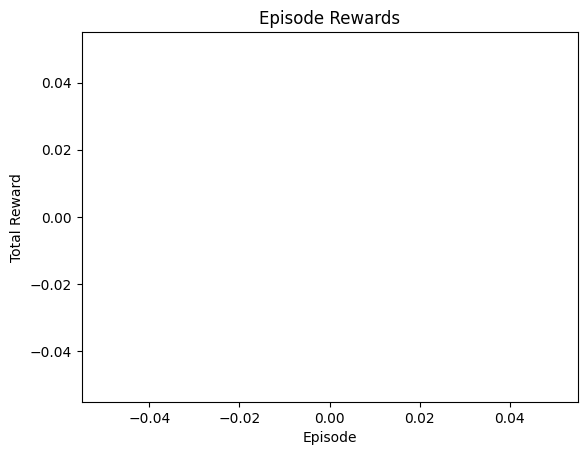

🚀 Training started...



e:\pjt\RL\Super Mario\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:335: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(


Ep 1/10 | Reward: 0.00 | ε: 1.000
Ep 2/10 | Reward: 0.00 | ε: 0.959
Ep 3/10 | Reward: 0.00 | ε: 0.917
Ep 4/10 | Reward: 0.00 | ε: 0.674
Ep 5/10 | Reward: 0.00 | ε: 0.591
Ep 6/10 | Reward: 1600.00 | ε: 0.507
Ep 7/10 | Reward: 0.00 | ε: 0.385
Ep 8/10 | Reward: 0.00 | ε: 0.277
Ep 9/10 | Reward: 0.00 | ε: 0.193
Ep 10/10 | Reward: 0.00 | ε: 0.122

✅ Training finished! 🎮 Video saved as mario_training.mp4


In [ ]:

import gymnasium as gym
import ale_py
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt
from collections import deque
from gymnasium.wrappers import GrayScaleObservation, ResizeObservation, FrameStack

# ---------- CONFIG ----------
ALLOWED_ACTIONS = [0, 1, 2, 3, 4]   # subset of controls
IMG_SIZE = (84, 84)
STACK = 4
RENDER_FREQ = 4                     # render every N frames
FONT = cv2.FONT_HERSHEY_SIMPLEX     # overlay font

# ---------- ENV SETUP ----------
env = gym.make("ALE/MarioBros-v5", render_mode="rgb_array")
env = GrayScaleObservation(env)
env = ResizeObservation(env, IMG_SIZE)
env = FrameStack(env, STACK)
obs_shape = env.observation_space.shape
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ Env ready | Obs shape: {obs_shape} | Device: {device}")

# ---------- DQN NETWORK ----------
class DQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super().__init__()
        c, h, w = input_shape
        self.net = nn.Sequential(
            nn.Conv2d(c, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3136, 512),
            nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = x / 255.0
        return self.net(x)

# ---------- REPLAY BUFFER ----------
class ReplayBuffer:
    def __init__(self, capacity=100_000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, ns, d = zip(*batch)
        return (
            np.array(s),
            np.array(a),
            np.array(r, dtype=np.float32),
            np.array(ns),
            np.array(d, dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)

# ---------- HELPERS ----------
def preprocess(obs):
    arr = np.array(obs)
    if arr.shape[-1] == STACK:
        arr = np.transpose(arr, (2, 0, 1))
    return arr

def select_action(state, epsilon, policy_net):
    if random.random() < epsilon:
        return random.randrange(len(ALLOWED_ACTIONS))
    with torch.no_grad():
        s = torch.tensor(state, device=device, dtype=torch.float32).unsqueeze(0)
        q_vals = policy_net(s)
        return int(q_vals.argmax(1).item())


n_policy_actions = len(ALLOWED_ACTIONS)
policy_net = DQN((STACK, *IMG_SIZE), n_policy_actions).to(device)
target_net = DQN((STACK, *IMG_SIZE), n_policy_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=1e-4)
replay = ReplayBuffer()
gamma = 0.99

# ---------- TRAINING CONFIG ----------
num_episodes = 10
batch_size = 32
epsilon_start = 1.0
epsilon_end = 0.05
epsilon_decay = 10000
target_update = 1000
global_step = 0
reward_history = []

# ---------- LIVE PLOT ----------
plt.ion()
fig, ax = plt.subplots()
ax.set_title("Episode Rewards")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
line, = ax.plot([], [], "b-")
plt.show(block=False)

# ---------- VIDEO WRITER ----------
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('mario_training.mp4', fourcc, 30.0, (160, 210))
print("🚀 Training started...\n")

# ---------- TRAINING ----------
for episode in range(num_episodes):
    obs, _ = env.reset()
    state = preprocess(obs)
    done = False
    total_reward = 0
    epsilon = max(epsilon_end, epsilon_start - global_step / epsilon_decay)
    frame_count = 0

    while not done:
        act_idx = select_action(state, epsilon, policy_net)
        env_action = ALLOWED_ACTIONS[act_idx]

        next_obs, reward, terminated, truncated, _ = env.step(env_action)
        done = terminated or truncated
        next_state = preprocess(next_obs)
        replay.push(state, act_idx, reward, next_state, done)
        state = next_state
        total_reward += reward
        global_step += 1
        frame_count += 1

        # ---------- LIVE VIDEO & OVERLAY ----------
        if frame_count % RENDER_FREQ == 0:
            frame = env.render()
            if frame is not None:
                frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

                # Overlay text (episode, step, epsilon, reward)
                overlay_text = [
                    f"Episode: {episode+1}/{num_episodes}",
                    f"Step: {global_step}",
                    f"Epsilon: {epsilon:.3f}",
                    f"Reward: {total_reward:.2f}",
                ]
                y0 = 20
                for i, txt in enumerate(overlay_text):
                    y = y0 + i * 20
                    cv2.putText(frame, txt, (8, y), FONT, 0.5, (0, 255, 0), 1, cv2.LINE_AA)

                cv2.imshow("Mario Live", frame)
                out.write(frame)  # Save to video file

                if cv2.waitKey(1) & 0xFF == ord("q"):
                    done = True
                    break

        # ---------- DQN TRAINING ----------
        if len(replay) > batch_size:
            s, a, r, ns, d = replay.sample(batch_size)
            s = torch.tensor(s, dtype=torch.float32, device=device)
            a = torch.tensor(a, dtype=torch.long, device=device).unsqueeze(1)
            r = torch.tensor(r, dtype=torch.float32, device=device)
            ns = torch.tensor(ns, dtype=torch.float32, device=device)
            d = torch.tensor(d, dtype=torch.float32, device=device)

            q_values = policy_net(s).gather(1, a).squeeze(1)
            with torch.no_grad():
                max_next_q = target_net(ns).max(1)[0]
                target_q = r + gamma * max_next_q * (1 - d)

            loss = nn.functional.smooth_l1_loss(q_values, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if global_step % target_update == 0:
            target_net.load_state_dict(policy_net.state_dict())

    reward_history.append(total_reward)

    # ---------- UPDATE REWARD PLOT ----------
    line.set_data(range(len(reward_history)), reward_history)
    ax.relim()
    ax.autoscale_view()
    plt.pause(0.001)

    print(f"Ep {episode+1}/{num_episodes} | Reward: {total_reward:.2f} | ε: {epsilon:.3f}")

# ---------- CLEANUP ----------
out.release()  # save the video
cv2.destroyAllWindows()
plt.ioff()
plt.show()
env.close()

print("\n✅ Training finished! 🎮 Video saved as mario_training.mp4")


## Trying to improve steps per episode
- Reward changed
- LR changed
- Actions changed
- Replay buffer changed


In [4]:
import gymnasium as gym
import ale_py
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
from collections import deque
import matplotlib
matplotlib.use("TkAgg")   # force GUI backend; do this before importing pyplot
import matplotlib.pyplot as plt

import cv2
import datetime
from gymnasium.wrappers import (
    GrayScaleObservation,
    ResizeObservation,
    FrameStack
)
import time

In [5]:
# Create/open log file
log_file = open("training_log.txt", "w", encoding="utf-8")

def log(msg):
    # print(msg)                   # still show on screen
    log_file.write(msg + "\n")   # also write to file
    log_file.flush()             # make sure it saves immediately



In [ ]:
# ACTION SPACE

ALLOWED_ACTIONS = [
    0,  # NOOP
    2,  # UP
    3,  # RIGHT
    4,  # LEFT
    7   # UP+RIGHT (jump)
]

# ENV SETUP

env = gym.make("ALE/MarioBros-v5", render_mode="rgb_array")
env = GrayScaleObservation(env)
env = ResizeObservation(env, (84, 84))
env = FrameStack(env, 4)

obs_shape = env.observation_space.shape
n_actions = len(ALLOWED_ACTIONS)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# DQN NETWORK

class DQN(nn.Module):
    def __init__(self, input_shape, n_actions):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3136, 512), nn.ReLU(),
            nn.Linear(512, n_actions)
        )

    def forward(self, x):
        x = x / 255.0
        return self.net(x)

# REPLAY BUFFER

class ReplayBuffer:
    def __init__(self, size=200_000):
        self.buffer = deque(maxlen=size)

    def push(self, s, a, r, ns, d):
        self.buffer.append((s, a, r, ns, d))

    def sample(self, batch):
        batch_data = random.sample(self.buffer, batch)
        return map(np.array, zip(*batch_data))

    def __len__(self):
        return len(self.buffer)

# SELECT ACTION

def select_action(state, epsilon):
    if random.random() < epsilon:
        return random.randrange(n_actions)
    with torch.no_grad():
        s = torch.tensor(state, device=device).unsqueeze(0)
        q = policy_net(s)
        return q.argmax(1).item()

# INIT NETWORKS

policy_net = DQN(obs_shape, n_actions).to(device)
target_net = DQN(obs_shape, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

optimizer = optim.Adam(policy_net.parameters(), lr=5e-5)
buffer = ReplayBuffer()

gamma = 0.99
batch_size = 32
target_update = 2000
global_step = 0
num_episodes = 200

# DISABLE LIVE PLOT

# plt.ion()
# fig, ax = plt.subplots()
# plt.show(block=False)
steps_list = []

# def update_plot():
#     ax.clear()
#     ax.plot(steps_list, label="Steps/Episode")
#     ax.set_xlabel("Episode")
#     ax.set_ylabel("Steps")
#     ax.set_title("Training Progress")
#     ax.legend(loc="upper left")
#     fig.canvas.draw()
#     fig.canvas.flush_events()
#     plt.pause(0.001)

# VIDEO WRITER (record only)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("mario_training.mp4", fourcc, 30.0, (160, 210))

# REMOVE LIVE GAMEPLAY WINDOW
# cv2.namedWindow("Mario Training", cv2.WINDOW_NORMAL)
# cv2.resizeWindow("Mario Training", 400, 350)

# TRAINING LOOP (Double DQN)

print("Training started...")

for ep in range(num_episodes):

    obs, _ = env.reset()
    state = np.array(obs)
    done = False
    total_reward = 0
    steps = 0

    epsilon = max(0.05, 1.0 - global_step / 50_000)

    while not done:
        steps += 1
        global_step += 1

        a_idx = select_action(state, epsilon)
        action = ALLOWED_ACTIONS[a_idx]

        next_obs, reward, terminated, truncated, info = env.step(action)
        next_state = np.array(next_obs)
        done = terminated or truncated

        shaped_reward = reward * 0.01 + 0.1
        buffer.push(state, a_idx, shaped_reward, next_state, done)

        state = next_state
        total_reward += shaped_reward

        # TRAIN
        if len(buffer) > batch_size:
            s, a, r, ns, d = buffer.sample(batch_size)

            s = torch.tensor(s, device=device, dtype=torch.float32)
            a = torch.tensor(a, device=device, dtype=torch.long).unsqueeze(1)
            r = torch.tensor(r, device=device)
            ns = torch.tensor(ns, device=device, dtype=torch.float32)
            d = torch.tensor(d, device=device, dtype=torch.float32)

            q_values = policy_net(s).gather(1, a).squeeze(1)
            next_actions = policy_net(ns).argmax(1)
            next_q = target_net(ns).gather(1, next_actions.unsqueeze(1)).squeeze(1)
            target = r + gamma * next_q * (1 - d)

            loss = nn.functional.smooth_l1_loss(q_values, target)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        if global_step % target_update == 0:
            target_net.load_state_dict(policy_net.state_dict())

        # VIDEO (NO LIVE WINDOW)
        
        frame = env.render()
        if frame is not None:
            text = f"Ep:{ep+1} Step:{steps}"
            cv2.putText(frame, text, (5, 15),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1)

            frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
            out.write(frame_bgr)

    # LOGGING
    log(f"Episode {ep+1}/{num_episodes} | "
        f"Steps: {steps} | "
        f"Raw reward: {reward} | "
        f"Shaped: {shaped_reward:.3f} | "
        f"Total: {total_reward:.3f} | "
        f"Epsilon: {epsilon:.3f}")

    steps_list.append(steps)
    if(ep%50==0): # Pause for 3 minutes (300 seconds) - need to cool off my cpu
        time.sleep(180)

    # NO LIVE PLOT
    # if ep % 10 == 0:
    #     update_plot()

env.close()
out.release()

# REMOVE LIVE GAMEPLAY CLOSE
# cv2.destroyAllWindows()

# REMOVE FINAL PLOT
# plt.ioff()
# plt.show()

log_file.close()

print("Training finished!")


Device: cpu
Training started...


e:\pjt\RL\Super Mario\.venv\Lib\site-packages\gymnasium\utils\passive_env_checker.py:335: UserWarning: WARN: No render fps was declared in the environment (env.metadata['render_fps'] is None or not defined), rendering may occur at inconsistent fps.
  logger.warn(


Training finished!


In [5]:
torch.save(policy_net.state_dict(), "mario_dqn.pth")
print("Model saved → mario_dqn.pth")


Model saved → mario_dqn.pth


In [7]:
torch.save({
    "policy": policy_net.state_dict(),
    "target": target_net.state_dict(),
    "optimizer": optimizer.state_dict(),
    "steps": global_step
}, "mario_checkpoint.pth")
